# Redocking Analysis for Acarbose Alternatives

**Project:** Acarbose Alternative Drug Discovery  
**Notebook Purpose:** Analyze redocking stability and score robustness across seeds   

**Key Questions**
- How stable are CNN_VS scores across redocking seeds?
- Do top-ranked ligands remain top-ranked under perturbation?
- How does the original docking compare to reseeded runs?

**High-Level Takeaways**
- (fill this in last)

## 1. Setup & Imports


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np

## 2. Data Loading

In [6]:
leads_2qmj = pd.read_parquet('../2qmj_vs.parquet')
leads_3baj = pd.read_parquet('../3baj_vs.parquet')
leads_5nn8 = pd.read_parquet('../5nn8_vs.parquet')

redocked_2qmj = pd.read_parquet('../2qmj_redock.parquet')
redocked_3baj = pd.read_parquet('../3baj_redock.parquet')
redocked_5nn8 = pd.read_parquet('../5nn8_redock.parquet')

## 3. Feature Engineering / Derived Metrics

In [8]:
leads_2qmj['cnn_vs'] = leads_2qmj['cnn_affinity'] * leads_2qmj['cnn_pose_score']
leads_2qmj = leads_2qmj.sort_values(by='cnn_vs', ascending=False)
leads_2qmj = leads_2qmj.drop_duplicates(subset='identifier')

leads_3baj['cnn_vs'] = leads_3baj['cnn_affinity'] * leads_3baj['cnn_pose_score']
leads_3baj = leads_3baj.sort_values(by='cnn_vs', ascending=False)
leads_3baj = leads_3baj.drop_duplicates(subset='identifier')

leads_5nn8['cnn_vs'] = leads_5nn8['cnn_affinity'] * leads_5nn8['cnn_pose_score']
leads_5nn8 = leads_5nn8.sort_values(by='cnn_vs', ascending=False)
leads_5nn8 = leads_5nn8.drop_duplicates(subset='identifier')

In [7]:
redocked_2qmj['cnn_vs'] = redocked_2qmj['cnn_affinity'] * redocked_2qmj['cnn_pose_score']
redocked_2qmj = redocked_2qmj.sort_values(by='cnn_vs', ascending=False)
redocked_2qmj = redocked_2qmj.drop_duplicates(subset='log_path')

redocked_3baj['cnn_vs'] = redocked_3baj['cnn_affinity'] * redocked_3baj['cnn_pose_score']
redocked_3baj = redocked_3baj.sort_values(by='cnn_vs', ascending=False)
redocked_3baj = redocked_3baj.drop_duplicates(subset='log_path')

redocked_5nn8['cnn_vs'] = redocked_5nn8['cnn_affinity'] * redocked_5nn8['cnn_pose_score']
redocked_5nn8 = redocked_5nn8.sort_values(by='cnn_vs', ascending=False)
redocked_5nn8 = redocked_5nn8.drop_duplicates(subset='log_path')


In [9]:
def enrich(input_df, redock_df):
    input_df['cnn_vs'] = input_df['cnn_affinity'] * input_df['cnn_pose_score']
    input_df = input_df.sort_values(by='cnn_vs', ascending=False)
    input_df = input_df.drop_duplicates(subset='identifier')
    input_df = input_df[input_df['identifier'].isin(redock_df['identifier'])]
    return input_df

In [10]:
leads_2qmj = enrich(leads_2qmj, redocked_2qmj)
leads_3baj = enrich(leads_3baj, redocked_3baj)
leads_5nn8 = enrich(leads_5nn8, redocked_5nn8)

In [ ]:
combined_2qmj = pd.concat([redocked_2qmj, leads_2qmj])
combined_3baj = pd.concat([redocked_3baj, leads_3baj])
combined_5nn8 = pd.concat([redocked_5nn8, leads_5nn8])

## 4. Analysis


In [97]:
def iqr(x: pd.Series) -> float:
    return x.quantile(0.75) - x.quantile(0.25)

def subset_mostly_active_ligands(
    df: pd.DataFrame,
    score_col: str = "cnn_vs",
    id_col: str = "identifier",
    n_poses: int = 6,
    min_pass: int = 5,
    threshold: float = 6.30,
    eps: float = 1e-6
) -> pd.DataFrame:

    agg = (
        df.groupby(id_col)[score_col]
          .agg(
              median_score="median",
              iqr_score=iqr,
              min_score="min",
              n_poses="count",
              n_pass=lambda x: (x >= threshold).sum()
          )
          .reset_index()
    )

    keep_ids = agg.loc[
        (agg["n_poses"] == n_poses) &
        (agg["n_pass"] >= min_pass),
        id_col
    ]

    out = df[df[id_col].isin(keep_ids)].copy()

    out = out.merge(
        agg[
            [id_col, "median_score", "iqr_score", "n_pass", "min_score"]
        ],
        on=id_col,
        how="left"
    )

    out["median_to_iqr"] = out["median_score"] / (out["iqr_score"] + eps)

    out = out.sort_values(
        by=["median_to_iqr", "n_pass"],
        ascending=[False, False]
    )

    return out


In [107]:
filtered_2qmj = subset_mostly_active_ligands(combined_2qmj)
filtered_3baj = subset_mostly_active_ligands(combined_3baj)
filtered_5nn8 = subset_mostly_active_ligands(combined_5nn8)

In [108]:
print(f'2QMJ Drug Candidates ({len(set(filtered_2qmj.identifier.to_list()))}): {set(filtered_2qmj.identifier.to_list())}')
print(f'3BAJ Drug Candidates ({len(set(filtered_3baj.identifier.to_list()))}): {set(filtered_3baj.identifier.to_list())}')
print(f'5NN8 Drug Candidates ({len(set(filtered_5nn8.identifier.to_list()))}): {set(filtered_5nn8.identifier.to_list())}')

2QMJ Drug Candidates (3): {'CNP0111740.3', 'CNP0475805.2', 'CNP0233949.3'}
3BAJ Drug Candidates (28): {'CNP0242138.5', 'CNP0146238.1', 'CNP0185842.19', 'CNP0146238.29', 'CNP0311995.7', 'CNP0101894.1', 'CNP0248825.5', 'CNP0279905.3', 'CNP0226732.3', 'CNP0156494.1', 'CNP0300103.1', 'CNP0174709.1', 'CNP0148265.4', 'CNP0032127.0', 'CNP0279421.3', 'CNP0179776.4', 'CNP0151519.1', 'CNP0212278.2', 'CNP0380330.4', 'CNP0249020.3', 'CNP0194690.3', 'CNP0162606.2', 'CNP0160390.3', 'CNP0200820.6', 'CNP0471067.0', 'CNP0064234.1', 'CNP0221124.1', 'CNP0299955.1'}
5NN8 Drug Candidates (6): {'CNP0533794.1', 'CNP0234543.1', 'CNP0111740.3', 'CNP0309854.1', 'CNP0240887.13', 'CNP0475805.2'}


## 5. Visualization

### 5.1. Distribution of CNN_VS of Initial Run vs. Redocking Seeds

**What this shows:**  
Each violin illustrates the histogram of CNN-VS scores all biologically active ligands (CNN-VS>=6.30) in the initial run (seed=123) vs. the redocking seeds.
* Is there clear separation between the leads and the redocked ligands?
* Performance across proteins as well.

**Why it matters:**  
This is our first look at if the CNN-VS scores remained stables across seeds. Instability would imply at least some of the initial leads were highly scored due to random chance.


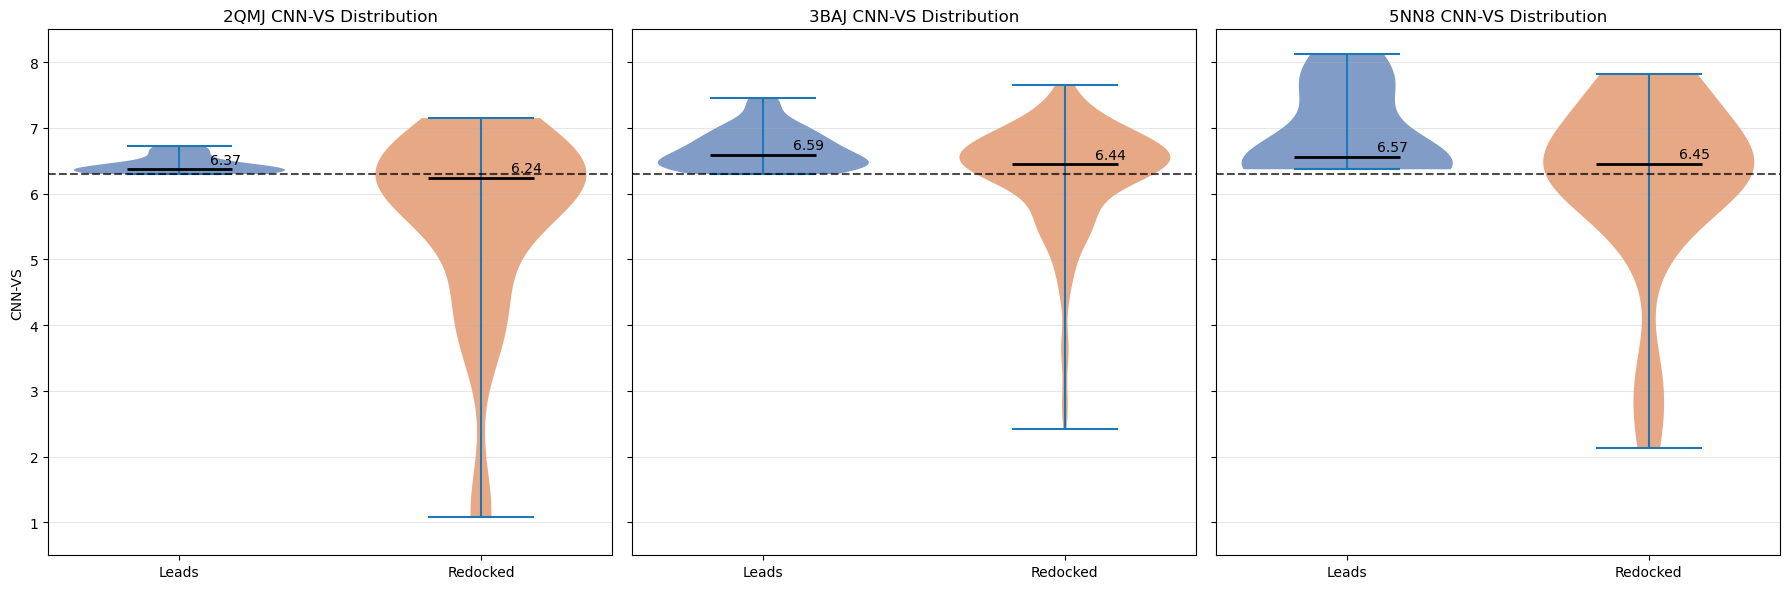

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

datasets = [
    ("2QMJ", leads_2qmj['cnn_vs'], redocked_2qmj['cnn_vs']),
    ("3BAJ", leads_3baj['cnn_vs'], redocked_3baj['cnn_vs']),
    ("5NN8", leads_5nn8['cnn_vs'], redocked_5nn8['cnn_vs']),
]

colors = ['#4C72B0', '#DD8452']  # Leads, Redocked

for ax, (label, leads, redocked) in zip(axes, datasets):
    data = [leads, redocked]

    vp = ax.violinplot(
        data,
        positions=[1, 2],
        showmeans=False,
        showmedians=True,
        widths=0.7
    )

    # color violins
    for body, color in zip(vp['bodies'], colors):
        body.set_facecolor(color)
        body.set_alpha(0.7)

    # style median lines
    vp['cmedians'].set_color('black')
    vp['cmedians'].set_linewidth(2)

    # annotate medians
    medians = [np.median(leads), np.median(redocked)]
    for x, med in zip([1, 2], medians):
        ax.text(
            x + 0.10,
            med + 0.15,
            f"{med:.2f}",
            va='center',
            fontsize=10
        )

    # biologically active threshold
    ax.axhline(
        y=6.30,
        linestyle='--',
        linewidth=1.5,
        color='black',
        alpha=0.7
    )

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Leads', 'Redocked'])
    ax.set_title(f'{label} CNN-VS Distribution')
    ax.set_ylim(0.5, 8.5)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_ylabel('CNN-VS')

plt.tight_layout()
plt.show()


### 5.2. Jittered Box-Plot of CNN-VS Distribution by Identifier Across All Seeds

**What this shows:**  
Each box shows the spread of CNN-VS scores for a given lead identifier across all seeds, including the original and redocking runs.
* Identifiers are ranked by median CNN-VS, shorthand for probability of biological activity.
* A sense of consistency vs variance per ligand.

**Why it matters:**  
This charts helps us see which identifiers have the most consistent CNN-VS scores, as well as if there distributions clear the biologically active threshold.

In [25]:
def add_seed_from_log_path(df: pd.DataFrame, log_col: str = "log_path") -> pd.DataFrame:
    out = df.copy()

    # extract digits after "seed_" anywhere in the path
    out["seed"] = out[log_col].astype(str).str.extract(r"seed_(\d+)", expand=False)

    # if no seed_### in path => original run
    out["run_type"] = np.where(out["seed"].isna(), "original", "redock")
    out["seed"] = out["seed"].fillna("original")

    # if you want numeric seeds too
    out["seed_num"] = pd.to_numeric(out["seed"], errors="coerce")

    return out

def best_pose_per_identifier_seed(df: pd.DataFrame, score_col: str = "cnn_vs") -> pd.DataFrame:
    # keep the best-scoring pose per (identifier, seed)
    return (
        df.sort_values(score_col, ascending=False)
          .drop_duplicates(subset=["identifier", "seed"], keep="first")
          .reset_index(drop=True)
    )

In [26]:
df2qmj = add_seed_from_log_path(combined_2qmj)
df2qmj = best_pose_per_identifier_seed(df2qmj)

df3baj = add_seed_from_log_path(combined_3baj)
df3baj = best_pose_per_identifier_seed(df3baj)

df5nn8 = add_seed_from_log_path(combined_5nn8)
df5nn8 = best_pose_per_identifier_seed(df5nn8)

In [49]:
def plot_box_jitter_per_identifier_ax(
    ax,
    df: pd.DataFrame,
    title: str,
    score_col="cnn_vs",
    y_min=0.5,
    y_max=8.5
):
    sub = df.copy()

    # order identifiers by median score
    order = (
        sub.groupby("identifier")[score_col]
           .median()
           .sort_values(ascending=False)
           .index.tolist()
    )

    data = [sub[sub["identifier"] == ident][score_col].values for ident in order]

    bp = ax.boxplot(
        data,
        tick_labels=[str(x) for x in order],
        showfliers=True,
        patch_artist=True
    )

    # style boxes
    for box in bp["boxes"]:
        box.set_facecolor("#4C72B0")
        box.set_alpha(0.6)

    # jitter points
    for i, ys in enumerate(data, start=1):
        x = np.random.normal(i, 0.06, size=len(ys))
        ax.scatter(x, ys, s=25, alpha=0.7)

    # biologically active threshold
    ax.axhline(
        y=6.30,
        linestyle="--",
        linewidth=1.5,
        color="black",
        alpha=0.7
    )

    ax.set_title(title)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel(score_col)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.3)


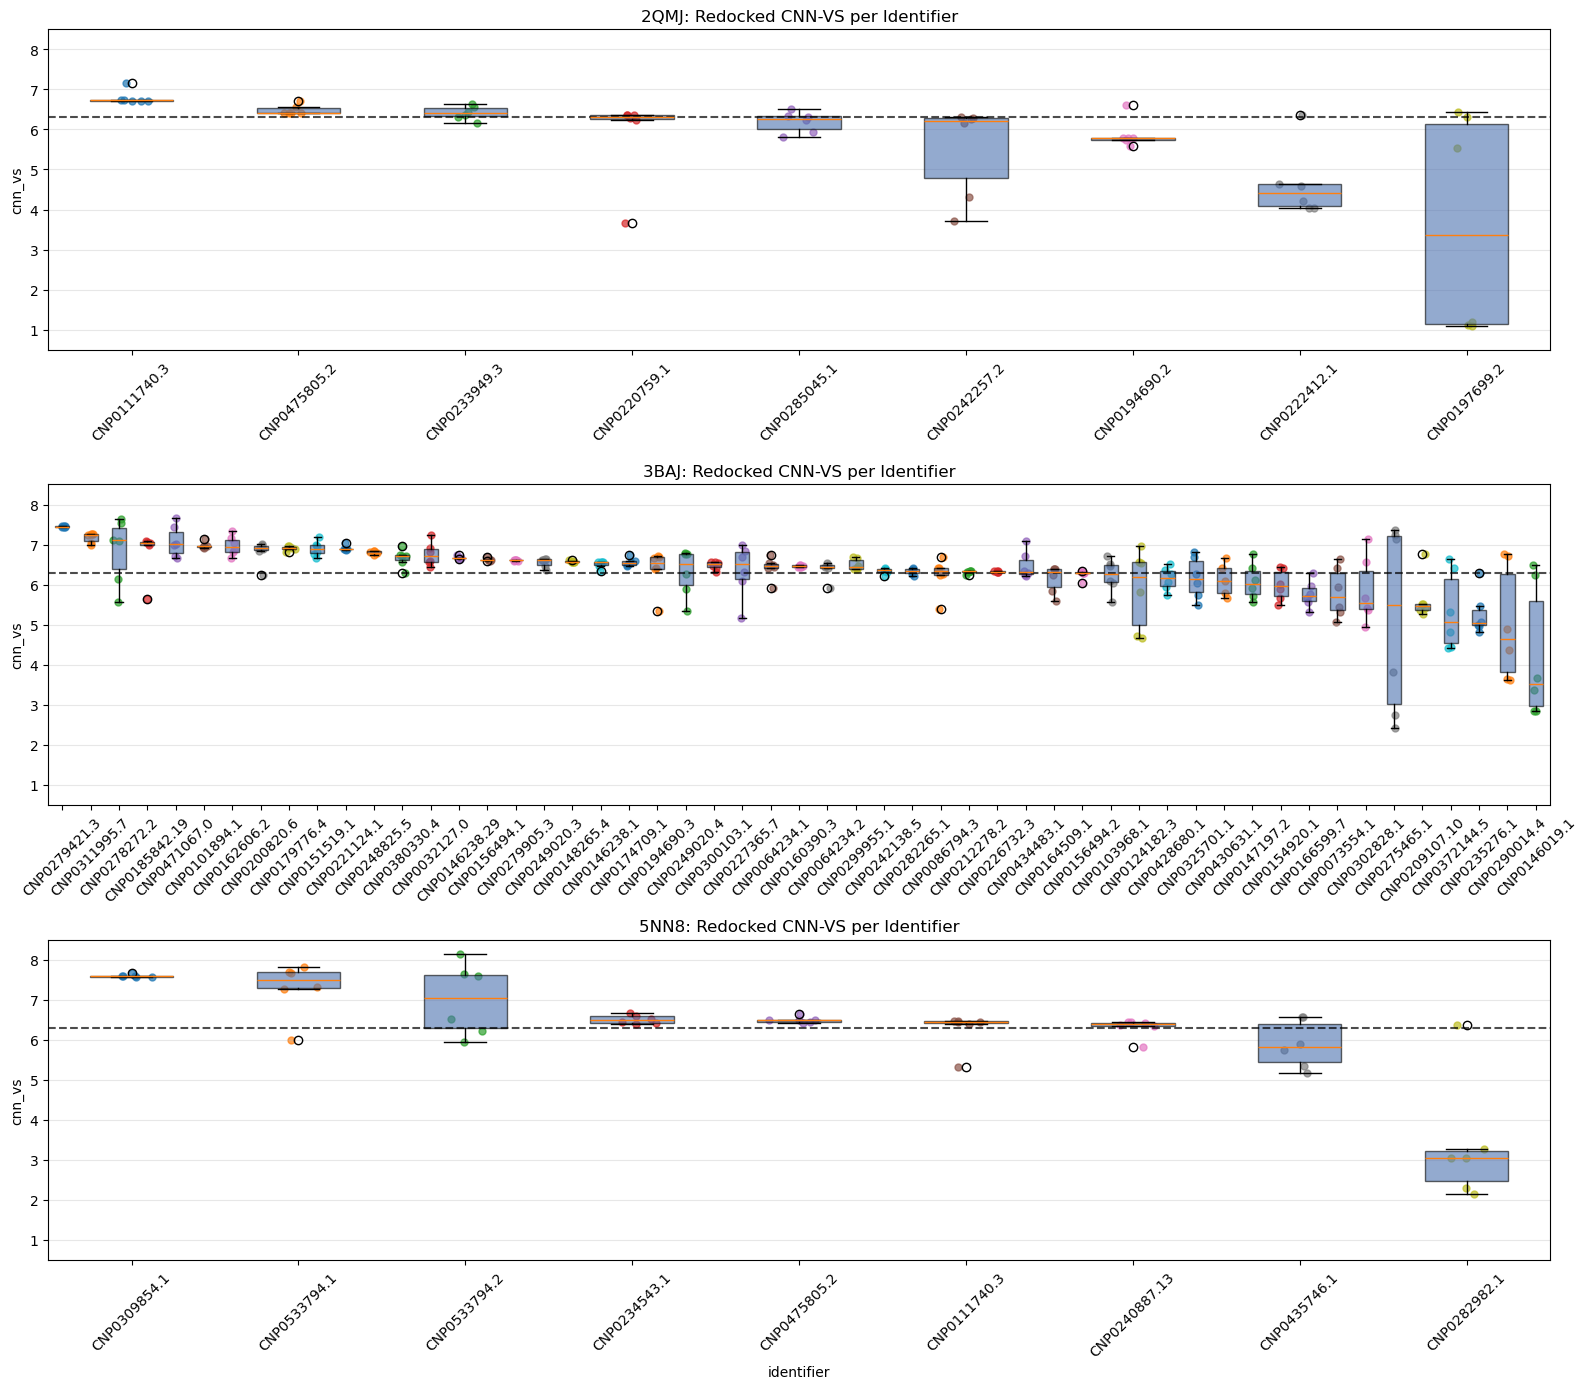

In [50]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharey=True)

plot_box_jitter_per_identifier_ax(
    axes[0],
    df2qmj,
    "2QMJ: Redocked CNN-VS per Identifier"
)

plot_box_jitter_per_identifier_ax(
    axes[1],
    df3baj,
    "3BAJ: Redocked CNN-VS per Identifier"
)

plot_box_jitter_per_identifier_ax(
    axes[2],
    df5nn8,
    "5NN8: Redocked CNN-VS per Identifier"
)

axes[-1].set_xlabel("identifier")

plt.tight_layout()
plt.show()

### 5.3. Spaghetti Plot of Best CNN-VS Score by Identifier Across All Seeds

**What this shows:**  
This is a closer look than the previous boxplot and show us seeds on the x-axis. Once again, it shows us the consistency and potency of each identifier:
* Which ligands are seed-stable vs. seed-sensitive?
* How often are trajectories exceeding 6.30?
* Are high medians due to lucky seeds or consistency?

**Why it matters:**  
These plots show us if CNN-VS scores are consistent across runs, as well as how high or low those scores are. We're looking for conisistent scoring that's also above the threshold.

In [56]:
def plot_spaghetti_ax(
    ax,
    df: pd.DataFrame,
    title: str,
    score_col="cnn_vs",
    y_min=0.5,
    y_max=8.5
):
    sub = df[df["run_type"] == "redock"].copy()

    # stable x ordering: numeric seed order
    seed_order = sorted(
        sub["seed_num"].dropna().unique().astype(int).tolist()
    )
    seed_to_x = {s: i for i, s in enumerate(seed_order, start=1)}
    sub["seed_x"] = sub["seed_num"].map(seed_to_x)

    # spaghetti lines: one per identifier
    for ident, g in (
        sub.sort_values("seed_x")
           .groupby("identifier")
    ):
        ax.plot(
            g["seed_x"],
            g[score_col],
            marker="o",
            linewidth=1,
            alpha=0.7
        )

    # biologically active threshold
    ax.axhline(
        y=6.30,
        linestyle="--",
        linewidth=1.5,
        color="black",
        alpha=0.7
    )

    ax.set_title(title)
    ax.set_ylabel(score_col)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(list(seed_to_x.values()))
    ax.set_xticklabels(
        [str(s) for s in seed_order],
        rotation=45,
        ha="right"
    )
    ax.grid(axis="y", alpha=0.3)


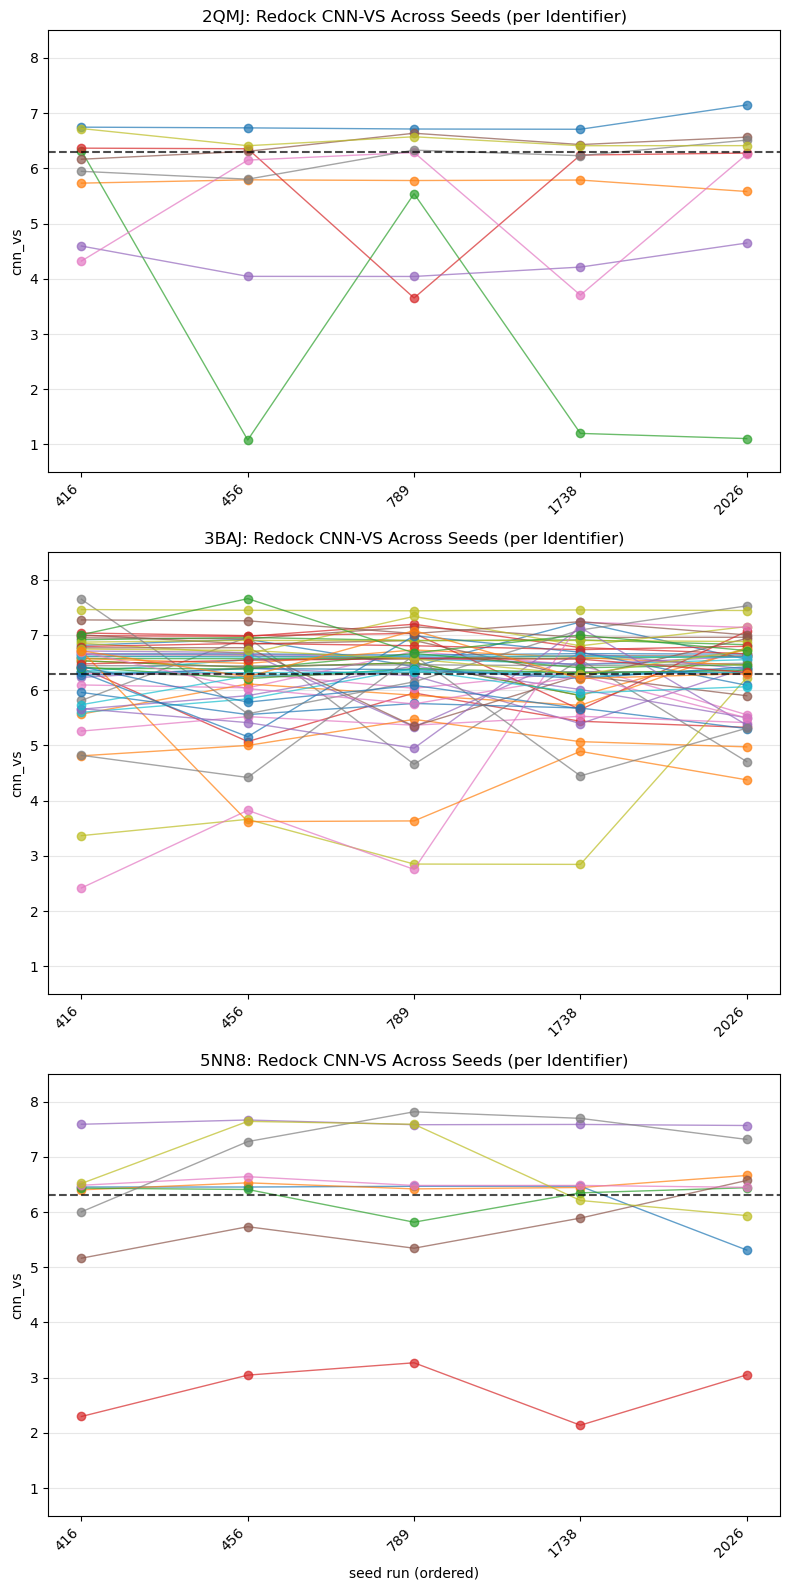

In [60]:
fig, axes = plt.subplots(3, 1, figsize=(8, 16), sharey=True)

plot_spaghetti_ax(
    axes[0],
    df2qmj,
    "2QMJ: Redock CNN-VS Across Seeds (per Identifier)"
)

plot_spaghetti_ax(
    axes[1],
    df3baj,
    "3BAJ: Redock CNN-VS Across Seeds (per Identifier)"
)

plot_spaghetti_ax(
    axes[2],
    df5nn8,
    "5NN8: Redock CNN-VS Across Seeds (per Identifier)"
)

axes[-1].set_xlabel("seed run (ordered)")

plt.tight_layout()
plt.show()

### 5.3. Scatter Plot of Cross-Seed Median CNN-VS Score & Cross-Seed Interquartile Range

**What this shows:**  
The median CNN-VS across seeds gives us a general idea of the CNN-VS for a particular ligand; the IQR is illustrative of stability/consistency of that CNN-VS. A lower IQR means a tighter distribution.
* Bottom-right quadrant: low variance, high CNN-VS (most promising candidates).
* Top-right quadrant: high variance, high CNN-VS (false positives).
* Top-left quadrant: high variance, low CNN-VS (discard).
* Bottom-left quadrant: low variance, low CNN-VS (true negatives)
* Are high medians due to lucky seeds or consistency?

**Why it matters:**  
These plots show us if CNN-VS scores are consistent across runs, as well as how high or low those scores are. We're looking for conisistent scoring that's also above the threshold.

In [ ]:
def plot_median_vs_iqr_ax(
    ax,
    df: pd.DataFrame,
    title: str,
    score_col="cnn_vs",
    x_min=0.5,
    x_max=8.5
):
    sub = df[df["run_type"] == "redock"].copy()

    agg = (
        sub.groupby("identifier")[score_col]
           .agg(
               median="median",
               q25=lambda x: np.quantile(x, 0.25),
               q75=lambda x: np.quantile(x, 0.75)
           )
           .reset_index()
    )
    agg["iqr"] = agg["q75"] - agg["q25"]

    ax.scatter(
        agg["median"],
        agg["iqr"],
        s=50,
        alpha=0.7
    )

    # label each point
    for _, r in agg.iterrows():
        ax.text(
            r["median"] + 0.03,
            r["iqr"],
            str(r["identifier"]),
            fontsize=8,
            alpha=0.9
        )

    # biologically active threshold
    ax.axvline(
        x=6.30,
        linestyle="--",
        linewidth=1.5,
        color="black",
        alpha=0.7
    )

    ax.set_title(title)
    ax.set_xlim(x_min, x_max)
    ax.set_ylabel("IQR across seeds\n(lower = more stable)")
    ax.grid(alpha=0.3)


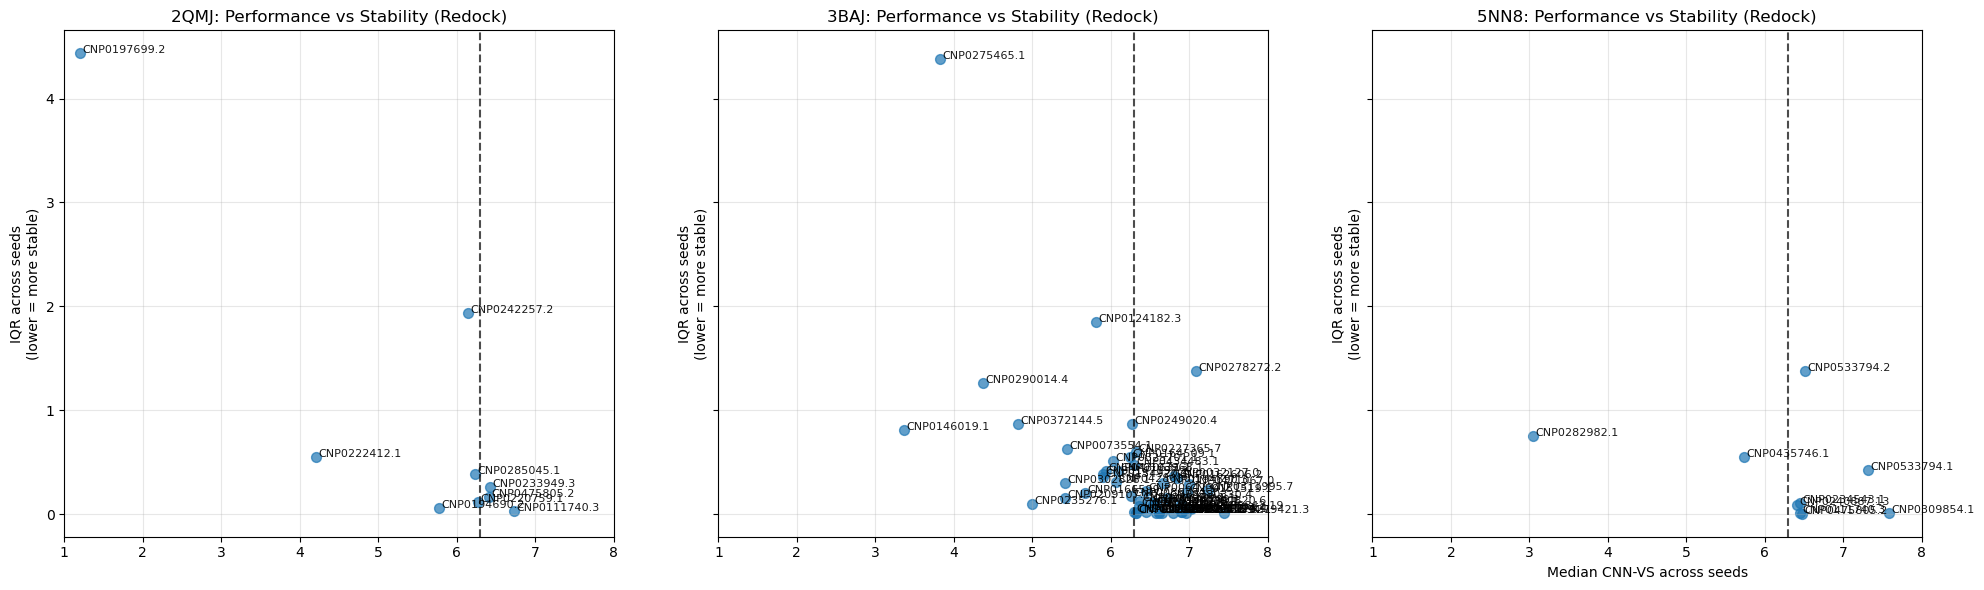

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True, sharex=True)

plot_median_vs_iqr_ax(
    axes[0],
    df2qmj,
    "2QMJ: Performance vs Stability (Redock)"
)

plot_median_vs_iqr_ax(
    axes[1],
    df3baj,
    "3BAJ: Performance vs Stability (Redock)"
)

plot_median_vs_iqr_ax(
    axes[2],
    df5nn8,
    "5NN8: Performance vs Stability (Redock)"
)

axes[-1].set_xlabel("Median CNN-VS across seeds")

plt.tight_layout()
plt.show()

### 5.4. Median Comparison Between Originals and Redock CNN-VS by Identifier

**What this shows:**  
This plot is one of the simpler visualizations; all we see here is the difference between the original run's CNN-VS and the median redock runs' CNN-VS.
* A small drop tells us our original run for that ligand was reliable.
* A big drop means it got lucky.

**Why it matters:**  
A companion to IQR vs. CNN-VS. A snapshot of pose stability.

In [75]:
def plot_original_vs_redock_median_ax(
    ax,
    df: pd.DataFrame,
    title: str,
    score_col="cnn_vs",
    y_min=0.5,
    y_max=8.5
):
    sub = df.copy()

    orig = (
        sub[sub["run_type"] == "original"]
        .groupby("identifier")[score_col]
        .max()
    )
    redk = (
        sub[sub["run_type"] == "redock"]
        .groupby("identifier")[score_col]
        .median()
    )

    both = (
        pd.concat(
            [orig.rename("original"), redk.rename("redock_median")],
            axis=1
        )
        .dropna()
        .sort_values("original", ascending=False)
    )

    x = np.arange(len(both))

    ax.scatter(
        x,
        both["original"],
        label="original",
        marker="o",
        s=50,
        alpha=0.8
    )
    ax.scatter(
        x,
        both["redock_median"],
        label="redock median",
        marker="x",
        s=60,
        alpha=0.8
    )

    # connecting lines
    for i, (a, b) in enumerate(
        zip(both["original"], both["redock_median"])
    ):
        ax.plot(
            [i, i],
            [a, b],
            linewidth=1,
            alpha=0.5,
            color="gray"
        )

    # biologically active threshold
    ax.axhline(
        y=6.30,
        linestyle="--",
        linewidth=1.5,
        color="black",
        alpha=0.7
    )

    ax.set_title(title)
    ax.set_ylim(y_min, y_max)
    ax.set_ylabel(score_col)
    ax.set_xticks(x)
    ax.set_xticklabels(
        both.index.astype(str),
        rotation=45,
        ha="right"
    )
    ax.grid(axis="y", alpha=0.3)


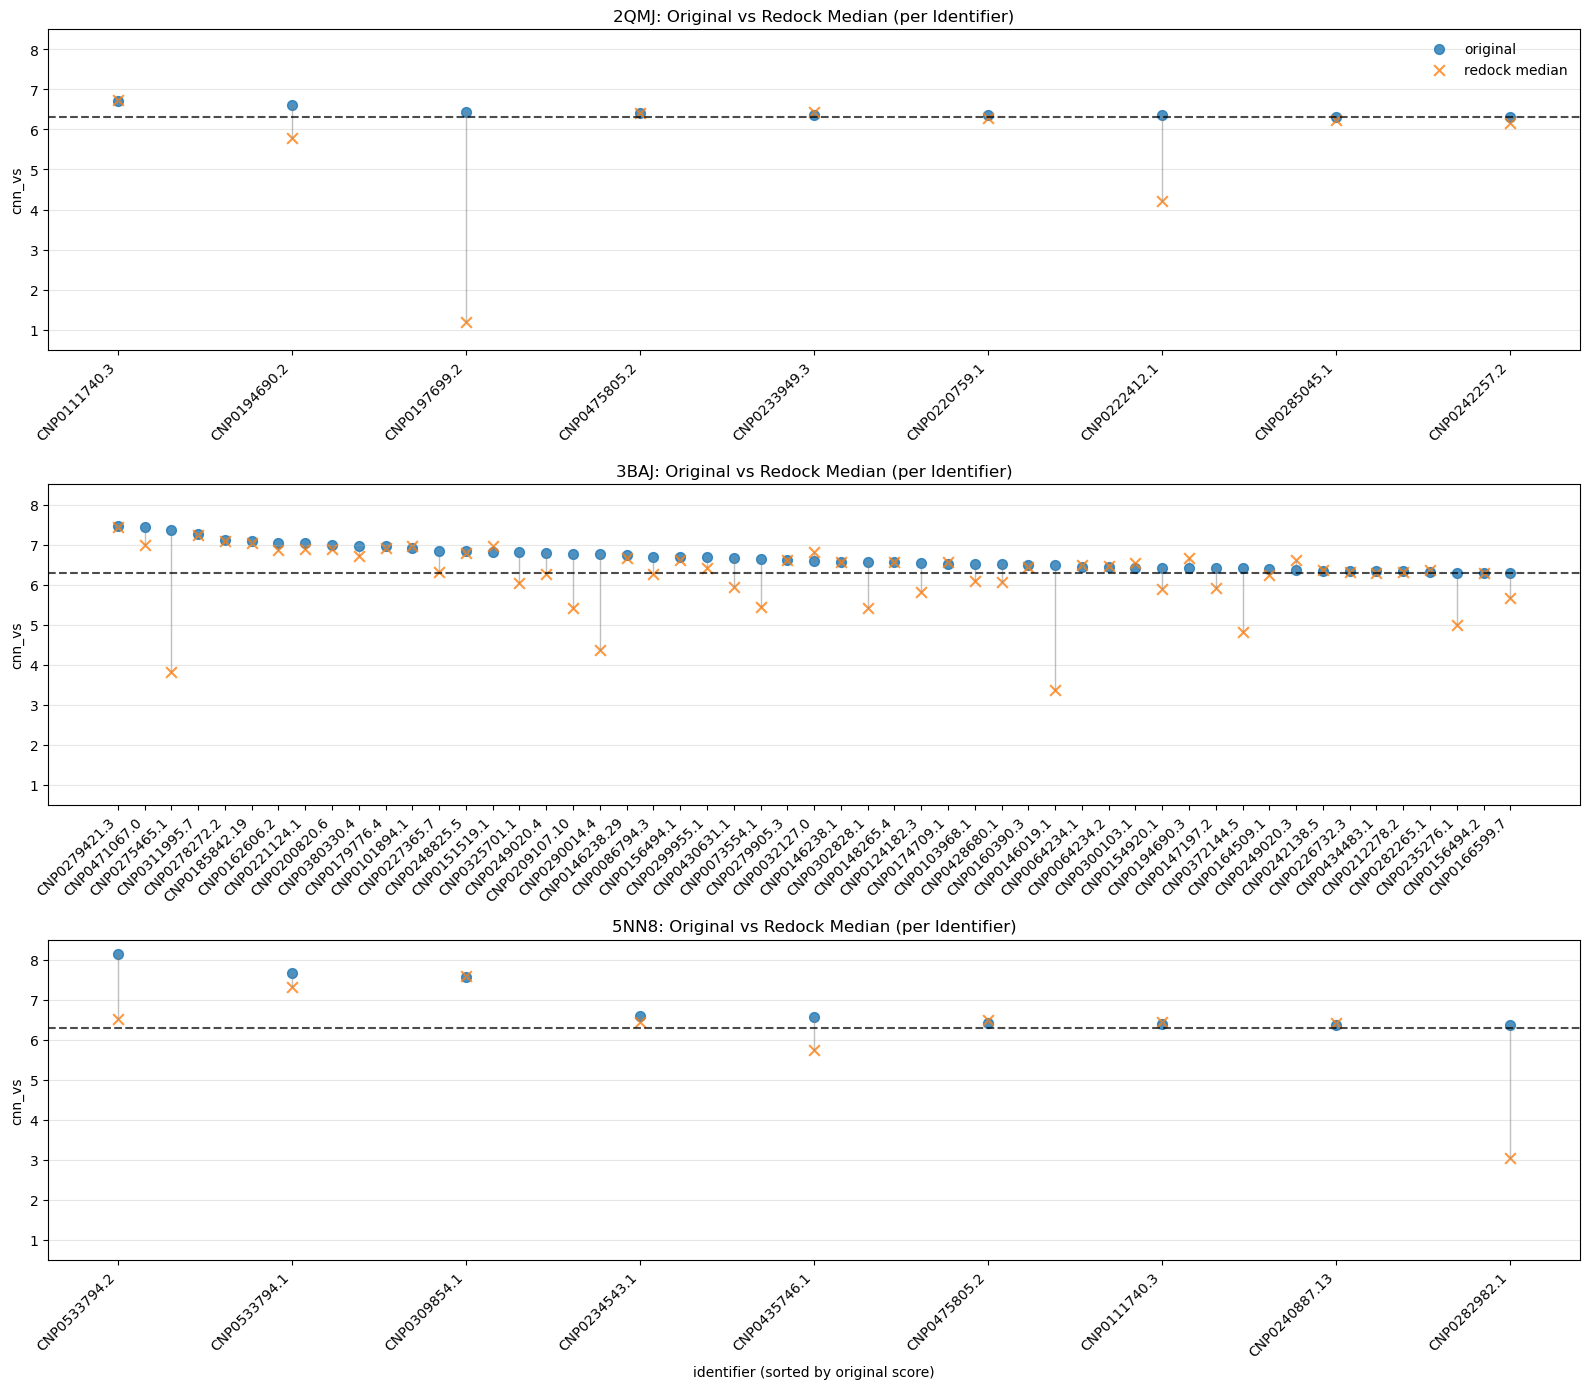

In [76]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharey=True)

plot_original_vs_redock_median_ax(
    axes[0],
    df2qmj,
    "2QMJ: Original vs Redock Median (per Identifier)"
)

plot_original_vs_redock_median_ax(
    axes[1],
    df3baj,
    "3BAJ: Original vs Redock Median (per Identifier)"
)

plot_original_vs_redock_median_ax(
    axes[2],
    df5nn8,
    "5NN8: Original vs Redock Median (per Identifier)"
)

axes[-1].set_xlabel("identifier (sorted by original score)")
axes[0].legend(frameon=False)

plt.tight_layout()
plt.show()

## 6. Results & Interpretation

Off the bat, we're able to isolate our top 3 candidates for each protein. These candidates are ranked by median CNN-VS across replicates to IQR ratio, ensuring that at least 5/6 replicates exceed a CNN-VS of 6.30:

* **2QMJ**: 'CNP0111740.3', 'CNP0475805.2', 'CNP0233949.3'
* **3BAJ**: 'CNP0242138.5', 'CNP0146238.1', 'CNP0185842.19'
* **5NN8**: 'CNP0533794.1', 'CNP0234543.1', 'CNP0111740.3'

As seen in Fig 5.3., most candidates tend to perform quite well along this metric, with strong overall clustering in the bottom-right quadrant (this is more visible with 3BAJ; while it may seem the case with the other proteins, there are actually probably too few candidates to tell).